In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

# =====================
# 配置
# =====================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 64
NUM_CLASSES = 2
T = 1000

# =====================
# 噪声调度（必须和训练一致）
# =====================
beta = torch.linspace(1e-4, 0.02, T).to(DEVICE)
alpha = 1. - beta
alpha_hat = torch.cumprod(alpha, dim=0)

# =====================
# 时间编码
# =====================
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        emb = torch.exp(
            torch.arange(half_dim, device=device) * -(math.log(10000) / (half_dim - 1))
        )

        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)

        return self.mlp(emb)

# =====================
# ResBlock
# =====================
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)

        self.emb_layer = nn.Linear(emb_dim, out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.relu(h)

        emb_out = self.emb_layer(emb).unsqueeze(-1).unsqueeze(-1)
        h = h + emb_out

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.relu(h)

        return h + self.shortcut(x)

# =====================
# Down
# =====================
class Down(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.res = ResBlock(in_channels, out_channels, emb_dim)

    def forward(self, x, emb):
        return self.res(self.pool(x), emb)

# =====================
# Up
# =====================
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.res = ResBlock(in_channels, out_channels, emb_dim)

    def forward(self, x1, x2, emb):
        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.res(x, emb)

# =====================
# UNet（带attention）
# =====================
class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        emb_dim = 128

        self.time_emb = TimeEmbedding(emb_dim)
        self.label_emb = nn.Embedding(num_classes, emb_dim)

        self.inc = ResBlock(3, 64, emb_dim)
        self.down1 = Down(64, 128, emb_dim)
        self.down2 = Down(128, 256, emb_dim)
        self.down3 = Down(256, 512, emb_dim)

        self.bot = ResBlock(512, 512, emb_dim)

        # attention
        self.attn = nn.MultiheadAttention(512, 4, batch_first=True)

        self.up1 = Up(512 + 256, 256, emb_dim)
        self.up2 = Up(256 + 128, 128, emb_dim)
        self.up3 = Up(128 + 64, 64, emb_dim)

        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x, t, labels):
        t = t / 1000.0

        t_emb = self.time_emb(t)
        l_emb = self.label_emb(labels)
        emb = t_emb + l_emb

        x1 = self.inc(x, emb)
        x2 = self.down1(x1, emb)
        x3 = self.down2(x2, emb)
        x4 = self.down3(x3, emb)

        x5 = self.bot(x4, emb)

        # attention
        b, c, h, w = x5.shape
        x_flat = x5.view(b, c, h*w).permute(0, 2, 1)
        x_attn, _ = self.attn(x_flat, x_flat, x_flat)
        x_attn = x_attn.permute(0, 2, 1).view(b, c, h, w)
        x5 = x5 + x_attn

        x = self.up1(x5, x3, emb)
        x = self.up2(x, x2, emb)
        x = self.up3(x, x1, emb)

        return self.outc(x)

# =====================
# 推理函数
# =====================
def generate_images(model_path, n=5):
    model = UNet(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    x = torch.randn(n, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    labels = torch.randint(0, NUM_CLASSES, (n,)).to(DEVICE)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=DEVICE, dtype=torch.long)

        with torch.no_grad():
            pred_noise = model(x, t_batch, labels)

        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = beta[t]

        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_hat_t)) * pred_noise
        ) + torch.sqrt(beta_t) * noise

    # 显示优化
    x = (x.clamp(-1,1) + 1) / 2

    fig, axs = plt.subplots(1, n, figsize=(12,3))
    for i in range(n):
        img = x[i].cpu().permute(1,2,0).numpy()
        axs[i].imshow(img)
        axs[i].set_title(f"class {labels[i].item()}")
        axs[i].axis('off')

    plt.show()


# =====================
# 直接运行
# =====================


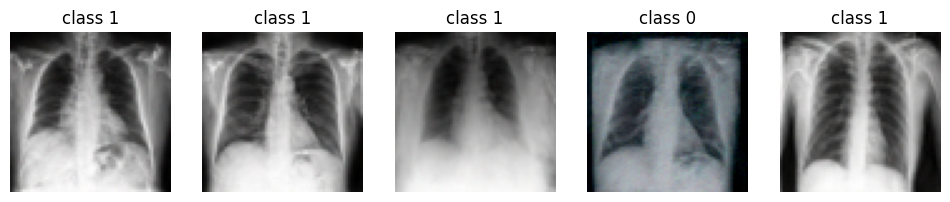

In [8]:
if __name__ == "__main__":
    generate_images("model2.pth", n=5)

In [9]:
import os
import torchvision.utils as vutils

def generate_cxr(model_path, n_per_class=50, save_dir="output"):
    # =====================
    # 创建保存目录
    # =====================
    os.makedirs(save_dir, exist_ok=True)

    # =====================
    # 加载模型
    # =====================
    model = UNet(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # =====================
    # 按类别生成
    # =====================
    for cls in range(NUM_CLASSES):
        print(f"Generating class {cls}...")

        # 每个类别单独文件夹
        class_dir = os.path.join(save_dir, f"class_{cls}")
        os.makedirs(class_dir, exist_ok=True)

        # 初始化噪声
        x = torch.randn(n_per_class, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        labels = torch.full((n_per_class,), cls, device=DEVICE, dtype=torch.long)

        # =====================
        # DDPM采样（原始版本）
        # =====================
        for t in reversed(range(T)):
            t_batch = torch.full((n_per_class,), t, device=DEVICE, dtype=torch.long)

            with torch.no_grad():
                pred_noise = model(x, t_batch, labels)

            alpha_t = alpha[t]
            alpha_hat_t = alpha_hat[t]
            beta_t = beta[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1 / torch.sqrt(alpha_t)) * (
                x - ((1 - alpha_t) / torch.sqrt(1 - alpha_hat_t)) * pred_noise
            ) + torch.sqrt(beta_t) * noise

        # =====================
        # 转换到 [0,1]
        # =====================
        x = (x.clamp(-1, 1) + 1) / 2

        # =====================
        # 保存图片
        # =====================
        for i in range(n_per_class):
            img = x[i]
            save_path = os.path.join(class_dir, f"img_{i}.png")
            vutils.save_image(img, save_path)

    print("✅ Generation complete!")

In [10]:
generate_cxr("model2.pth", n_per_class=50, save_dir="output")

Generating class 0...
Generating class 1...
✅ Generation complete!
